# Candidate360 Confident/Unconfident Dataset Classifier


## 1. Import the required libraries

In [8]:
import glob
import json
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import (
    image_dataset_from_directory,
    img_to_array,
    load_img,
    set_random_seed
)

warnings.filterwarnings("ignore")


## 2. Reproducibility

In [9]:
seed = 100
random.seed(seed)
np.random.seed(seed)
set_random_seed(seed)


## 3. Attach the Kaggle dataset

In [11]:
DATA_DIR = ("/kaggle/input/datasets/sougatganguly/confident-unconfident/confident-unconfident")

TRAIN_DIR = DATA_DIR + "/train"
TEST_DIR = DATA_DIR + "/test"

train_image_paths = glob.glob(
    TRAIN_DIR + "/*/*")

test_image_paths = glob.glob(
    TEST_DIR + "/*/*")

print(
    "Training images:",
    len(train_image_paths))

print(
    "Testing images:",
    len(test_image_paths))

if (
    len(train_image_paths) == 0
    or len(test_image_paths) == 0):
    raise FileNotFoundError(
        "The dataset was not found. In Kaggle, select Add Input "
        "and attach sougatganguly/confident-unconfident.")


Training images: 28707
Testing images: 7178


## 4. Exploratory data analysis and class balance

,train,test
confident,12179,3007
unconfident,16528,4171


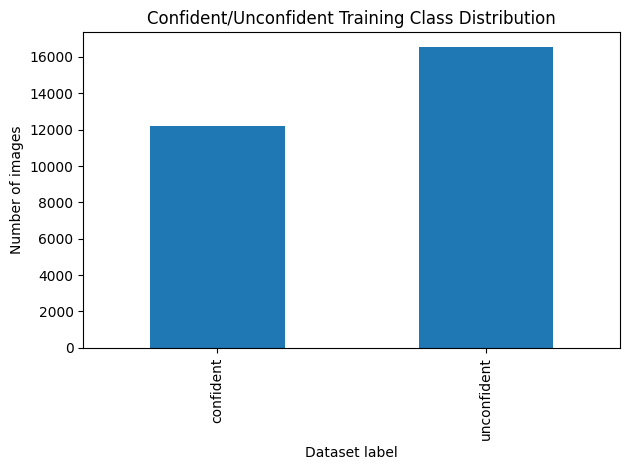

In [13]:
train_labels = [
    path.split("/")[-2]
    for path in train_image_paths]

test_labels = [
    path.split("/")[-2]
    for path in test_image_paths]

train_counts = (
    pd.Series(train_labels)
    .value_counts()
    .sort_index())

test_counts = (
    pd.Series(test_labels)
    .value_counts()
    .sort_index())

display(
    pd.DataFrame({
        "train": train_counts,
        "test": test_counts}))

train_counts.plot(
    kind="bar",
    title=(
        "Confident/Unconfident "
        "Training Class Distribution"))

plt.xlabel("Dataset label")
plt.ylabel("Number of images")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "confidence_class_distribution.png")

plt.show()


## 5. Create train, validation and untouched test datasets

In [14]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="training",
    seed=seed,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="int",
    shuffle=True)

val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="validation",
    seed=seed,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="int",
    shuffle=True)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="int",
    shuffle=False)

class_names = train_ds.class_names

expected_class_names = [
    "confident",
    "unconfident"]

assert class_names == expected_class_names
assert val_ds.class_names == class_names
assert test_ds.class_names == class_names

print("Class order:", class_names)


Found 28707 files belonging to 2 classes.
Using 22966 files for training.


I0000 00:00:1787866633.039197      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787866633.042503      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 28707 files belonging to 2 classes.
Using 5741 files for validation.
Found 7178 files belonging to 2 classes.
Class order: ['confident', 'unconfident']


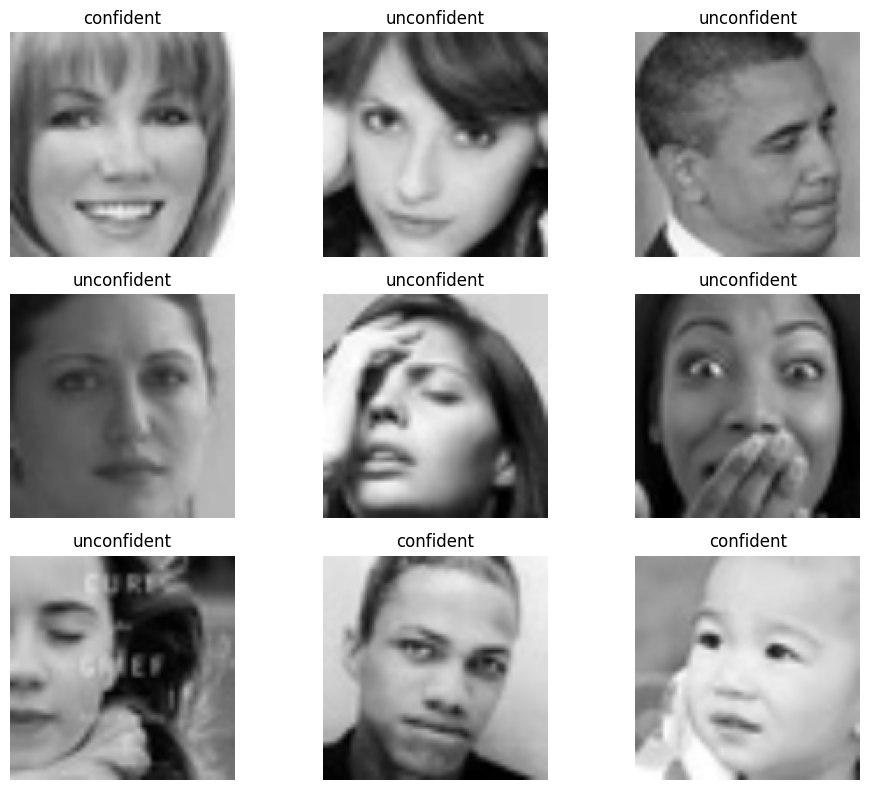

In [15]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow(
            images[index]
            .numpy()
            .astype("uint8"))

        plt.title(
            class_names[
                int(labels[index])])

        plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "confidence_sample_images.png")

plt.show()


## 6. Build the Xception transfer-learning model

In [16]:
backbone = Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3))

backbone.trainable = False

inputs = Input(
    shape=(128, 128, 3))

x = preprocess_input(inputs)
x = backbone(x)
x = GlobalAveragePooling2D()(x)

outputs = Dense(
    len(class_names),
    activation="softmax")(x)

model = Model(
    inputs=inputs,
    outputs=outputs)

model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 4, 4, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,865,578 (79.60 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

Xception's `preprocess_input` is saved inside the model. Candidate360 should therefore send raw RGB pixels to the saved model and must not divide the pixels by 255 again.

## 7. Compile and train for 100 epochs

In [17]:
checkpoint_filepath = (
    "/kaggle/working/"
    "confidence_model.keras")
if os.path.exists(
    checkpoint_filepath):
    os.remove(
        checkpoint_filepath)

model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor="val_accuracy",
    save_weights_only=False,
    mode="max",
    save_best_only=True,
    verbose=1)

model.compile(
    loss=(
        "sparse_categorical_"
        "crossentropy"),
    metrics=["accuracy"])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=[
        model_checkpoint_callback])


Epoch 1/100


2026-08-27 21:39:39.870153: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:39:40.017528: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:39:41.010120: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:39:41.144973: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:39:42.029449: E external/local_xla/xla/stream_

716/718 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6781 - loss: 0.6073

2026-08-27 21:40:18.416217: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:40:18.560347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:40:19.458334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:40:19.593230: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:40:20.422902: E external/local_xla/xla/stream_

718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6782 - loss: 0.6073

2026-08-27 21:40:40.339314: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:40:40.479617: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:40:41.280458: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:40:41.414788: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 21:40:42.235544: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.70145, saving model to /kaggle/working/confidence_model.keras

Epoch 1: finished saving model to /kaggle/working/confidence_model.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 78s 84ms/step - accuracy: 0.6990 - loss: 0.5837 - val_accuracy: 0.7014 - val_loss: 0.5694
Epoch 2/100
717/718 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7247 - loss: 0.5457
Epoch 2: val_accuracy improved from 0.70145 to 0.71137, saving model to /kaggle/working/confidence_model.keras

Epoch 2: finished saving model to /kaggle/working/confidence_model.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.7293 - loss: 0.5421 - val_accuracy: 0.7114 - val_loss: 0.5595
Epoch 3/100
717/718 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7399 - loss: 0.5293
Epoch 3: val_accuracy improved from 0.71137 to 0.71730, saving model to /kaggle/working/confidence_model.keras

Epoch 3: finished saving model to /kaggle/working/confidence_model.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 37s 

## 8. Plot and save the training curves

,accuracy,loss,val_accuracy,val_loss
0,0.698990,0.583706,0.701446,0.569427
1,0.729295,0.542098,0.711374,0.559508
2,0.742794,0.527621,0.717297,0.557849
3,0.747104,0.517756,0.741683,0.531215
4,0.750631,0.510816,0.739418,0.534441
...,...,...,...,...
95,0.778586,0.481520,0.726354,0.637579
96,0.780458,0.480734,0.708587,0.649834
97,0.778063,0.481981,0.730535,0.623275
98,0.781198,0.480197,0.731057,0.644528


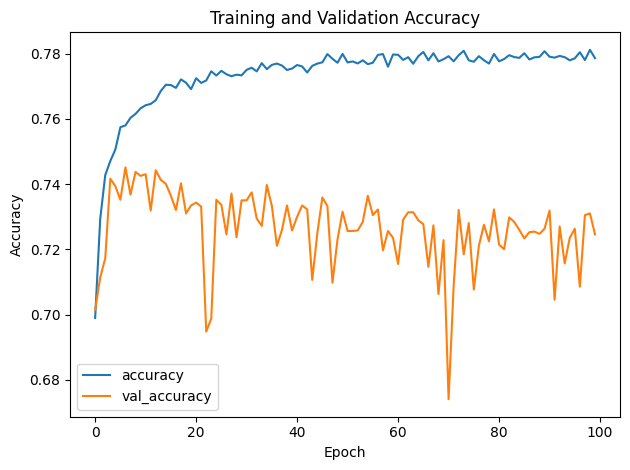

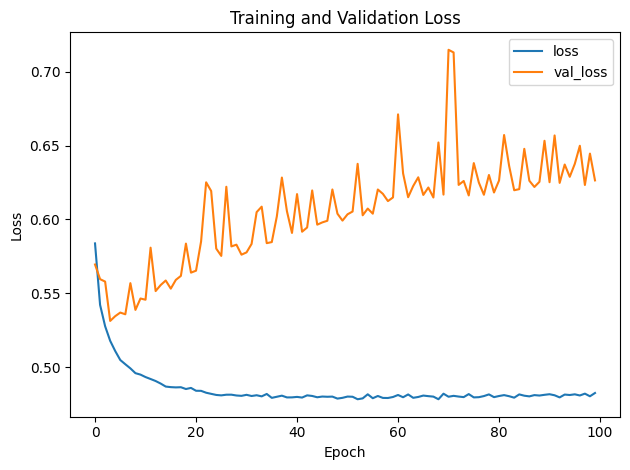

In [18]:
history_df = pd.DataFrame(
    history.history
)

display(history_df)

history_df[
    ["accuracy", "val_accuracy"]
].plot(
    title=(
        "Training and Validation "
        "Accuracy"))

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "confidence_accuracy_curve.png")

plt.show()

history_df[
    ["loss", "val_loss"]
].plot(
    title=(
        "Training and Validation "
        "Loss"))

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "confidence_loss_curve.png")

plt.show()


## 9. Evaluate the best model on untouched test data

In [19]:
best_model = load_model(
    checkpoint_filepath)

test_loss, test_accuracy = (
    best_model.evaluate(test_ds))

print(
    "Test loss:",
    test_loss)

print(
    "Test accuracy:",
    test_accuracy)


223/225 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6732 - loss: 0.6609

2026-08-27 22:54:41.523967: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 22:54:41.662563: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 22:54:42.437757: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 22:54:42.572205: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 22:54:43.388347: E external/local_xla/xla/stream_

225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 88ms/step - accuracy: 0.7350 - loss: 0.5437
Test loss: 0.5437213182449341
Test accuracy: 0.7350236773490906


In [20]:
y_test = np.concatenate([
    labels.numpy()
    for images, labels in test_ds])

y_probability = best_model.predict(
    test_ds)

y_pred = np.argmax(
    y_probability,
    axis=1)

majority_class = np.bincount(
    y_test.astype(int)).argmax()

baseline_pred = np.full_like(
    y_test,
    majority_class)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred)

model_accuracy = accuracy_score(
    y_test,
    y_pred)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro")

print(
    "Majority-class baseline accuracy:",
    baseline_accuracy)

print(
    "Model accuracy:",
    model_accuracy)

print(
    "Macro F1-score:",
    macro_f1)

report_text = classification_report(
    y_test,
    y_pred,
    target_names=class_names)

print(report_text)

report_dictionary = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True)

report_dataframe = pd.DataFrame(
    report_dictionary).transpose()

display(report_dataframe)

report_dataframe.to_csv(
    "/kaggle/working/"
    "confidence_classification_report.csv")


225/225 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step
Majority-class baseline accuracy: 0.581081081081081
Model accuracy: 0.7350236834772917
Macro F1-score: 0.7233250355840746
              precision    recall  f1-score   support

   confident       0.71      0.63      0.67      3007
 unconfident       0.75      0.81      0.78      4171

    accuracy                           0.74      7178
   macro avg       0.73      0.72      0.72      7178
weighted avg       0.73      0.74      0.73      7178



,precision,recall,f1-score,support
confident,0.705009,0.631859,0.666433,3007.000000
unconfident,0.753067,0.809398,0.780217,4171.000000
accuracy,0.735024,0.735024,0.735024,0.735024
macro avg,0.729038,0.720629,0.723325,7178.000000
weighted avg,0.732935,0.735024,0.732551,7178.000000


## 10. Confusion matrix

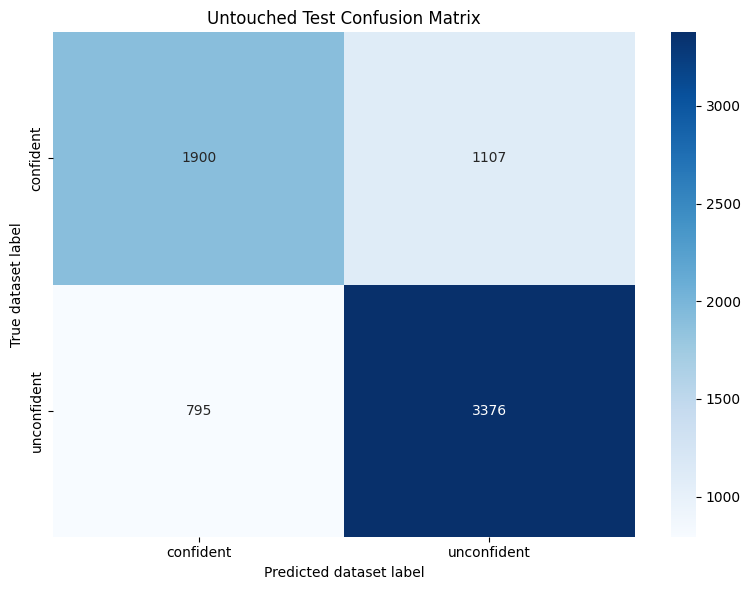

In [21]:
conf_matrix = confusion_matrix(
    y_test,
    y_pred)

plt.figure(
    figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Blues",
    fmt="g",
    xticklabels=class_names,
    yticklabels=class_names)

plt.xlabel(
    "Predicted dataset label")

plt.ylabel(
    "True dataset label")

plt.title(
    "Untouched Test Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "confidence_confusion_matrix.png")

plt.show()


## 11. Qualitative error analysis

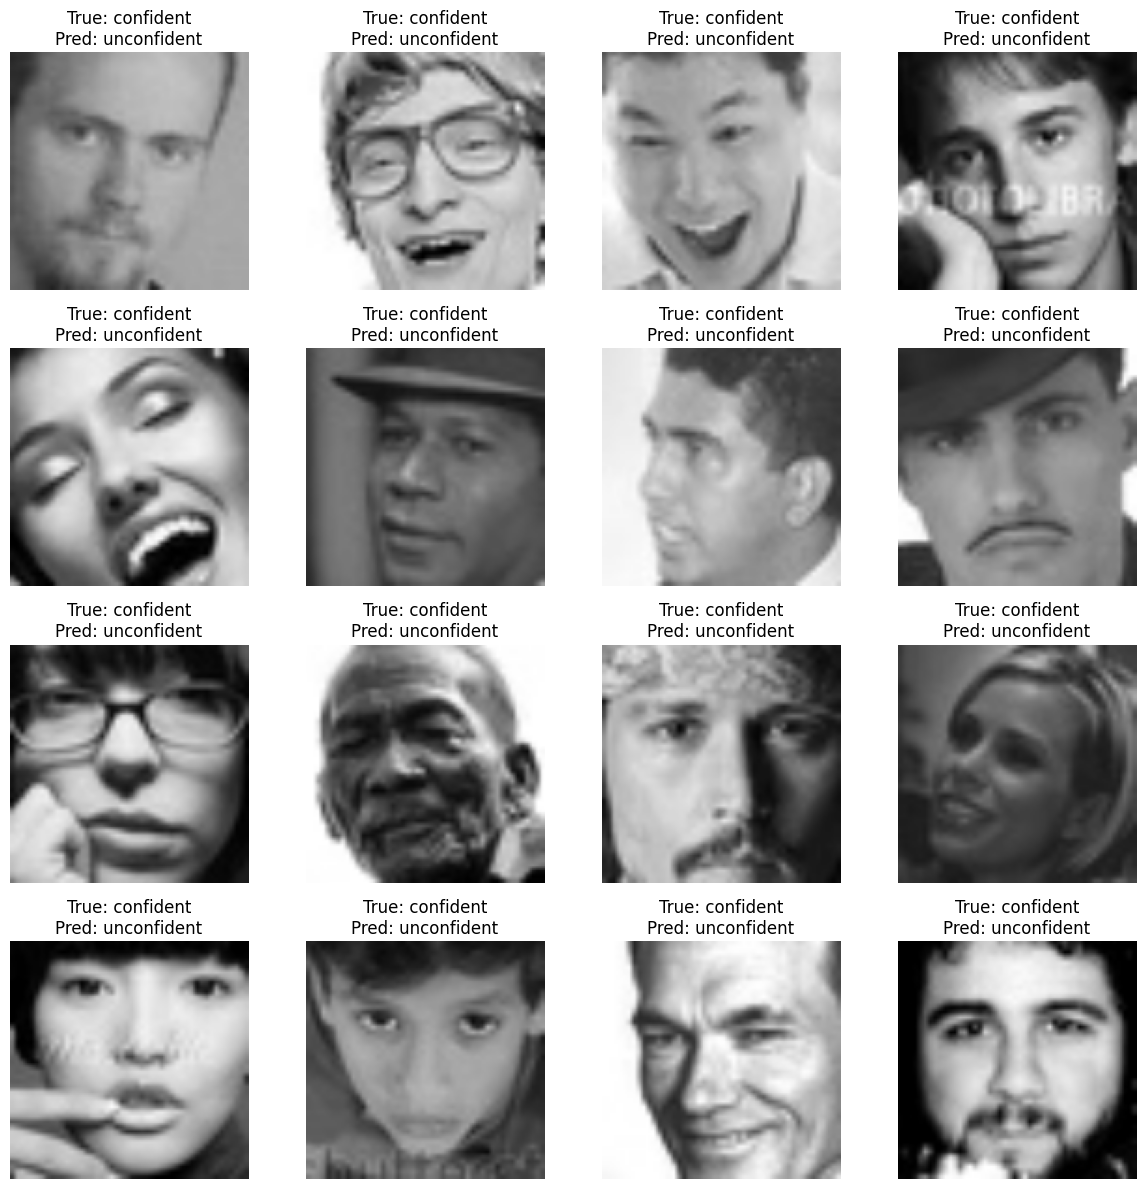

In [22]:
test_images = np.concatenate([
    images.numpy()
    for images, labels in test_ds])

wrong_indices = np.where(
    y_test != y_pred)[0]

plt.figure(
    figsize=(12, 12))

for index, image_index in enumerate(
    wrong_indices[:16]):
    plt.subplot(
        4,
        4,
        index + 1)

    plt.imshow(
        test_images[image_index]
        .astype("uint8"))

    true_name = class_names[
        int(y_test[image_index])]

    predicted_name = class_names[
        int(y_pred[image_index])]

    plt.title(
        f"True: {true_name}\n"
        f"Pred: {predicted_name}")

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "confidence_error_examples.png")

plt.show()


### Error-analysis questions

1. Which label is confused most often?
2. Do dark, side-facing, covered or blurred faces appear among the errors?
3. Does the class imbalance affect precision or recall?
4. Could the manually assigned labels be visually ambiguous?
5. Could dataset or cultural bias affect how the model generalises?

Describe visible patterns as possible explanations, not proven causes.


## 12. Test one picture before deployment

In [23]:
def predict_confidence_image(
    image_path,
    trained_model,
    labels):
    image = load_img(
        image_path,
        target_size=IMG_SIZE)

    image_array = img_to_array(
        image)

    image_array = np.expand_dims(
        image_array,
        axis=0)

    prediction = trained_model.predict(
        image_array,
        verbose=0)[0]

    results = []

    for label, score in zip(
        labels,
        prediction):
        results.append({
            "label": label,
            "score": float(score)})

    return sorted(
        results,
        key=lambda item: item["score"],
        reverse=True)

example_image_path = test_image_paths[0]

print(
    "Example image:",
    example_image_path)

print(
    predict_confidence_image(
        example_image_path,
        best_model,
        class_names))


Example image: /kaggle/input/datasets/sougatganguly/confident-unconfident/confident-unconfident/test/unconfident/PublicTest_78686873.jpg


2026-08-27 23:00:15.290484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 23:00:15.437104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 23:00:15.570271: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 23:00:16.325329: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 23:00:16.457626: E external/local_xla/xla/stream_

[{'label': 'unconfident', 'score': 0.7947168350219727}, {'label': 'confident', 'score': 0.20528317987918854}]


## 13. Save the model labels and evaluation results

In [24]:
class_names_filepath = (
    "/kaggle/working/"
    "confidence_class_names.json")

results_filepath = (
    "/kaggle/working/"
    "confidence_evaluation_results.json")

with open(
    class_names_filepath,
    "w",
    encoding="utf-8") as class_file:
    json.dump(
        class_names,
        class_file,
        indent=2)

results = {
    "dataset": (
        "sougatganguly/"
        "confident-unconfident"
    ),
    "interpretation": (
        "Subjective confident/unconfident "
        "dataset labels; not verified "
        "confidence or nervousness."
    ),
    "majority_baseline_accuracy": float(
        baseline_accuracy
    ),
    "test_loss": float(test_loss),
    "test_accuracy": float(
        test_accuracy
    ),
    "macro_f1": float(macro_f1),
    "number_of_test_images": int(
        len(y_test)
    ),
    "class_names": class_names,
    "classification_report": (
        report_dictionary)}

with open(
    results_filepath,
    "w",
    encoding="utf-8") as result_file:
    json.dump(
        results,
        result_file,
        indent=2,
        default=float)

deployment_model = load_model(
    checkpoint_filepath)

assert (
    deployment_model.output_shape[-1]
    == len(class_names))

assert class_names == [
    "confident",
    "unconfident"]

print(
    "Deployment verification passed.")

print(
    "\nDownload these files "
    "from /kaggle/working/:")

print(
    "confidence_model.keras")

print(
    "confidence_class_names.json")

print(
    "confidence_evaluation_results.json")

print(
    "confidence_classification_report.csv")

print(
    "confidence_class_distribution.png")

print(
    "confidence_sample_images.png")

print(
    "confidence_accuracy_curve.png")

print(
    "confidence_loss_curve.png")

print(
    "confidence_confusion_matrix.png")

print(
    "confidence_error_examples.png")


Deployment verification passed.

Download these files from /kaggle/working/:
confidence_model.keras
confidence_class_names.json
confidence_evaluation_results.json
confidence_classification_report.csv
confidence_class_distribution.png
confidence_sample_images.png
confidence_accuracy_curve.png
confidence_loss_curve.png
confidence_confusion_matrix.png
confidence_error_examples.png
